### 1. Project Overview

This project aims to develop a trading strategy capable of predicting corruent day market price range. Specifically, The goal is to forecast potential upward and downward deviations range from the market's opening price within a single trading session.The primary objective is to apply quantitative modeling techniques and machine learning methods to intraday price movements, rather than to achieve high predictive accuracy.

Data for this project are from the SPDR Gold Trust ETF (GLD), a widely traded exchange-traded fund that seeks to track the price of physical gold. GLD provides investors with exposure to gold price movements without requiring them to engage in the complexities of trading futures contracts or handling physical gold. By analyzing GLD, this study leverages a liquid and accessible asset that closely reflects gold price dynamics. This choice is align with our focus on forecasting high and low deviations from the market’s opening price.

In this analysis, I used a suite of libraries to source, preprocess, model, and evaluate the financial data. Yahoo Finance (yfinance) was utilized to import historical data. Pandas and NumPy were essential for efficient data manipulation, allowing me to transform, aggregate, and manage time series data. To standardize and preprocess the dataset, I used scikit-learn’s StandardScaler and SimpleImputer, incorporated within a Pipeline for seamless data handling and transformation. I also employed scikitlearn for Linear Regression as a foundational model, leveraging TimeSeriesSplit for time-aware cross-validation and GridSearchCV for optimized hyperparameter tuning. The performance analysis and risk assessment of the strategy were conducted using pyfolio, which provided detailed insights into return metrics and risk-adjusted performance. Finally, Matplotlib was used to visualize data trends and model predictions, enhancing the interpretability of the results and aiding in the communication of key insights.

In [9]:
# Importing necessary libraries 
import yfinance as yf
import pandas as pd
import numpy as np
import pyfolio as pf 
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression
from sklearn.pipeline import Pipeline 
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import TimeSeriesSplit
import matplotlib.pyplot as plt
%matplotlib inline
plt.style.use('seaborn-v0_8-darkgrid')

# To ignore unwanted warnings
import warnings
warnings.filterwarnings("ignore")

#### Data Prepration :


[*********************100%%**********************]  1 of 1 completed


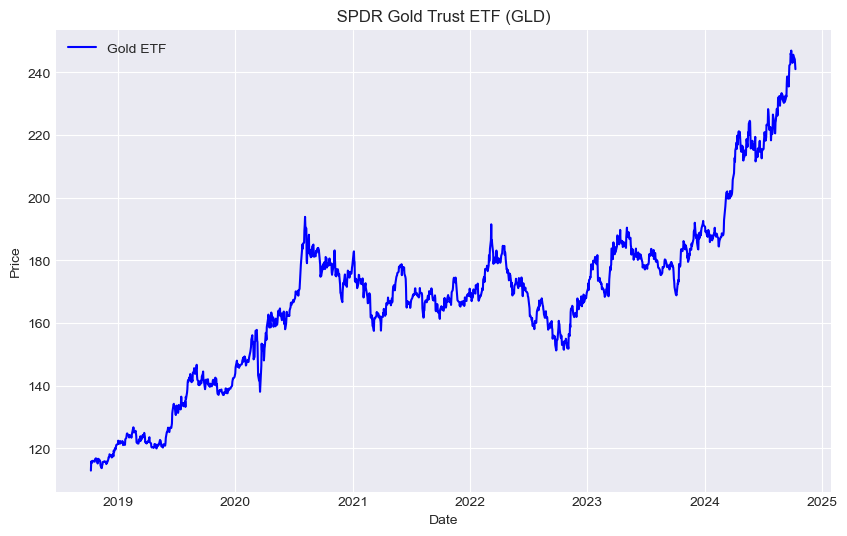

In [10]:
# Fetching historical data
ticker ='GLD' 
GLD = yf.download(ticker, start= '2018-10-10', end= '2024-10-10')
GLD_df = GLD.drop(['Adj Close', 'Volume'], axis=1)
# Ensuring data is Fetched
if GLD_df.empty: 
    raise exception("Failed to download data from ticker")

# Plotting GLD chart
plt.figure(figsize=(10,6))
plt.plot(GLD_df['Close'], label='Gold ETF',color='blue')
plt.title(' SPDR Gold Trust ETF (GLD) ')
plt.xlabel('Date')
plt.ylabel('Price')
plt.legend()
plt.grid(True)
plt.show()

In [11]:
GLD_df.isna().sum()

Open     0
High     0
Low      0
Close    0
dtype: int64

### 2. Data Collection And  Preprocessing 
The OHLCV DataFrame we're using contains time series data with fields for Open, High, Low, Close, Volume, and Adjusted Close prices. After removing the Volume and Adjusted Close columns, we need to prepare the remaining data for modeling. This will involve data preprocessing and manipulation, as well as the creation of key predictive indicators, which are outlined as follows:  

###### Custom Indicators
To calculate custom indicators, we start with:
- **STD\_U** (Upward price movement) for the day, defined as:
  $$ \text{STD_U} = \text{Open} - \text{High} $$
- **STD\_D** (Downward price movement) for the day, defined as:
  $$ \text{STD_D} = \text{Open} - \text{Low} $$

###### Customise Moving Averages (MA)
We add 3-day, 15-day, and 60-day moving averages, which help us analyze both short-term and long-term price trends:
$$ \text{MA}_n = \frac{1}{n} \sum_{i=1}^{n} \text{Price}_i $$

where \( n \) is the number of days (3, 15, or 60).

###### Price Change Indicator
To observe daily opening momentum, we calculate the difference between today’s open and yesterday’s open:
$$ \Delta \text{Open} = \text{Open}_{\text{today}} - \text{Open}_{\text{yesterday}} $$

###### Correlation Indicator
Using the Pandas correlation function, we add a correlation metric to see the relationship between today’s closing price and the 3-day moving average.

###### Overnight Change
Finally, we calculate overnight price changes by comparing today’s open with the previous day’s close:
$$ \text{Overnight Change} = \text{Open}_{\text{today}} - \text{Close}_{\text{yesterday}} $$


In [12]:
# Calculate 3, 15, and 60 days MA of close prices
GLD_df['MA_3'] = GLD_df['Close'].shift(1).rolling(window=3).mean()
GLD_df['MA_15'] = GLD_df['Close'].shift(1).rolling(window=15).mean()
GLD_df['MA_60'] = GLD_df['Close'].shift(1).rolling(window=60).mean()

# Calculate the correlation between 3 days MA and trading Session Close prices
GLD_df['Corr'] = GLD_df['Close'].shift(1).rolling(window=10).corr(GLD_df['MA_3'].shift(1))

# Calculate the difference between High & Open, Open & Low
GLD_df['Std_U'] = GLD_df['High']-GLD_df['Open']
GLD_df['Std_D'] = GLD_df['Open']-GLD_df['Low']

# Calculate the difference between `Open` & previous day's `Open`, and `Open` & previous day's `Close`
GLD_df['OD'] = GLD_df['Open']-GLD_df['Open'].shift(1)
GLD_df['OL'] = GLD_df['Open']-GLD_df['Close'].shift(1)

GLD_df.tail()

,Open,High,Low,Close,MA_3,MA_15,MA_60,Corr,Std_U,Std_D,OD,OL
Date,,,,,,,,,,,,
2024-10-03,244.720001,245.910004,243.690002,245.490005,244.776667,241.913999,230.678666,0.717001,1.190002,1.029999,-0.889999,-0.940002
2024-10-04,245.000000,246.690002,244.050003,245.000000,245.586670,242.524666,231.114167,0.578269,1.690002,0.949997,0.279999,-0.490005
2024-10-07,244.580002,244.820007,243.809998,244.169998,245.383336,242.946000,231.476667,0.291136,0.240005,0.770004,-0.419998,-0.419998
2024-10-08,243.789993,244.039993,240.630005,242.369995,244.886668,243.313333,231.827666,-0.514362,0.250000,3.159988,-0.790009,-0.380005
2024-10-09,241.160004,241.839996,240.639999,241.050003,243.846664,243.648666,232.136666,-0.373007,0.679993,0.520004,-2.629990,-1.209991


##### Creating X and y data set 
we will feed input datasets and yU and yDfor feeding into the machine learning linear regression model that we are going to build. The model has two dependent variables, $ y_U $ (for upward deviation) and $ y_D $ (for downward deviation), and a set of independent variables $ X_t $. The independent variables include the features:

$$
X_t = \left[ \text{MA}_{3,t}, \text{MA}_{15,t}, \text{MA}_{60,t}, OD_t, OL_t, \text{Corr}_t \right]
$$

where each $ X_t $ contains the values of the predictors (Moving Averages, Operational Metrics, etc.) at time $ t $, and $ \text{Corr}_t $ represents the correlation at time $ t $, which can be written as:

##### Time Series Regression Model for :

For predicting the upward deviation $ y_{U,t} $ at time \( t \), we can use a linear regression model:

$$
y_{U,t} = \beta_0 + \beta_1 \cdot \text{MA}_{3,t} + \beta_2 \cdot \text{MA}_{15,t} + \beta_3 \cdot \text{MA}_{60,t} + \beta_4 \cdot OD_t + \beta_5 \cdot OL_t + \beta_6 \cdot \text{Corr}_t + \epsilon_{U,t}
$$

Similarly, for the downward deviation $ y_{D,t} $ at time \( t \), the model would be:

$$
y_{D,t} = \alpha_0 + \alpha_1 \cdot \text{MA}_{3,t} + \alpha_2 \cdot \text{MA}_{15,t} + \alpha_3 \cdot \text{MA}_{60,t} + \alpha_4 \cdot OD_t + \alpha_5 \cdot OL_t + \alpha_6 \cdot \text{Corr}_t + \epsilon_{D,t}
$$

where:
- $ X_t $ is the feature vector at time $ t $,
- $ \beta $ and $ \alpha $ are the learned coefficients for each model (upward and downward deviation, respectively),
- $ \epsilon_{U,t} $ and $ \epsilon_{D,t} $ are the error terms for each prediction.


In [36]:
# Independent variable 
X = GLD_df[['Open','MA_3','MA_15','MA_60','OD','OL','Corr',]]
X.isna().sum()

Open     0
MA_3     0
MA_15    0
MA_60    0
OD       0
OL       0
Corr     0
dtype: int64

In [37]:
# Depenedent variable for upward deviation 
yU = GLD_df['Std_U']
# Dependent varibale for downward deviation 
yD = GLD_df['Std_D']

In [38]:
GLD_df.isna().sum()

Open     0
High     0
Low      0
Close    0
MA_3     0
MA_15    0
MA_60    0
Corr     0
Std_U    0
Std_D    0
OD       0
OL       0
dtype: int64

We have 60 NaN values in `MA_60`, 15 NaN values in `MA_15`,13 NaN values in `Corr` and 3 NaN values in `MA_3` etc. Now we will simply drop all the NaN values using `dropna'. 

In [39]:
# Dropping all the NaN
GLD_df.dropna(inplace=True)

# Checking for NaN values
GLD_df.isna().sum()

Open     0
High     0
Low      0
Close    0
MA_3     0
MA_15    0
MA_60    0
Corr     0
Std_U    0
Std_D    0
OD       0
OL       0
dtype: int64

#### Feature Scaling, Imputation And Pipeline Integration 

To ensure that the model can learn effectively from all features, we standardized the dataset and handled missing data through imputation. First, we observed that certain features had variances significantly larger than others, which could dominate the objective function and impair the model's ability to learn correctly. To prevent this, we applied the Standard Scaler function, which centered the data (by reducing the mean to zero) and scaled it (by dividing each entry by the standard deviation, making it equal to one). This standardization is crucial for predictive models, especially for linear regression, where the model performs best when the feature magnitudes are similar.

For the missing values in the dataset, we chose to replace them with the most frequent value (mode) rather than the mean or median. The mean can distort the distribution and underestimate the standard deviation, leading to potential errors. The median alters the data's mean, which might not be desirable in some cases. The mode, however, preserves the distribution's integrity while addressing missing values, which is why we used it. This approach was implemented in the pipeline using the SimpleImputer function with the strategy set to 'most_frequent'. We then combined this step with the scaling and regression steps in a pipeline for seamless processing.

In [40]:
# Setting steps of the pipeline
steps = [
    ('imputer', SimpleImputer(missing_values=np.nan, strategy='most_frequent')),  
    ('scaler', StandardScaler()),                
    ('linear', LinearRegression())]
# Defining the pipeline 
pipeline = Pipeline(steps)

#### Hyperparameters

In machine learning, certain parameters, known as hyperparameters, cannot be estimated directly from the training data but are essential for optimizing model performance. For our linear regression model, we focus on the intercept as a key hyperparameter. By tuning this hyperparameter, we aim to enhance the model's accuracy and overall performance.

To determine whether the intercept should be included, we use the fit_intercept function. This boolean function allows us to decide if the model should compute an intercept (value of 1) or omit it (value of 0), based on which configuration yields the best results. This simple yet crucial step helps fine-tune the model for better predictive accuracy.

In [41]:
# Using intercept of the linear model as a hyperparameter 
parameters = {'linear__fit_intercept': [0, 1]}

In [42]:
GLD_df.isna().sum()

Open     0
High     0
Low      0
Close    0
MA_3     0
MA_15    0
MA_60    0
Corr     0
Std_U    0
Std_D    0
OD       0
OL       0
dtype: int64

#### Grid Search Cross-Validation
 To assess the model’s performance in real-world scenarios and mitigate overfitting, we implement cross-validation. We utilize the GridSearchCV function, an efficient tool for performing exhaustive search over specified hyperparameters, ensuring that the model generalizes well.

We set cv=5 for the grid search, meaning the data will be split into five subsets for cross-validation, providing a robust performance evaluation by averaging the results across these rounds. We opt for GridSearchCV over RandomizedSearchCV due to the relatively smaller number of features in our model, making a grid search more efficient. Additionally, we use TimeSeriesSplit for partitioning the training data, ensuring that temporal dependencies are respected when splitting the data. This comprehensive approach helps fine-tune model parameters, like the intercept, to achieve optimal performance.

In [43]:
# Spliting the time series for Grid Search Cross Validation
kf = TimeSeriesSplit(n_splits=5)

# Defining reg as a variable for Gridserech function contatining pipeline, Hyperparameter 
reg = GridSearchCV(pipeline, parameters, cv=kf)

#### Split Train and Test Data

Now, we will split data into train and test data sets. 

1. First, 70% of data is used for training and the remaining data for testing.
2. Fit the training data to a grid search function.

In [44]:
Splitting_ratio = 0.7
# Splitting the data into two parts
# Using int to make sure integer number comes out.
split = int(Splitting_ratio*len(GLD_df))

# Defining train dataset
X_train = X[:split]
yU_train = yU[:split]
yD_train = yD[:split]

# Defining test data
X_test = X[split:]

#### Predicting Market High and Low Values Using Linear Regression

we will apply the linear regression model to the training dataset and use it to predict upward deviations in the test dataset. These predictions will serve as the foundation for developing a trading application. Specifically, we will predict deviations in the high and low prices relative to the opening price. To generate actual market predictions, we will add and subtract these deviations from the open price, respectively, to obtain the predicted market highs and lows.

We will create two new columns in the dataframe, max_u and max_d, to store the predicted values. However, we must address a key practical consideration: while the linear regression model can generate negative predictions, it is not realistic for the high of the day to be lower than the opening price or for the low to be higher. To account for this, we will trim the predictions to ensure they fall within feasible ranges. Finally, we will calculate the predicted high (p_h) by adding max_u to the open price, and the predicted low (p_l) by subtracting max_d from the open price, populating these values in new columns. This process bridges the model's predictions to actionable trading insights.


In [45]:
# fit model
reg.fit(X_train, yU_train)

# Print best parameter
print(reg.best_params_)

{'linear__fit_intercept': 1}


In [46]:
# Predict the upward deviation
yU_predict = reg.predict(X_test)

In [47]:
# Fit the model
reg.fit(X_train, yD_train)

# Print best parameter
print(reg.best_params_)

# Predict the downward deviation
yD_predict = reg.predict(X_test)

{'linear__fit_intercept': 1}


Now we will create `yU_predict` and `yD_predict` columns in the `X_test`.Formulas for upward deviation and downward deviation are given by:

Upward deviation  = High - Open

Downward deviation = Open - Low

It is clear from the above two formulas that upward and downward deviation can not be negative. So, we replace negative values with zero.


In [48]:
# Create new column in X_test
X_test['yU_predict'] = yU_predict
X_test['yD_predict'] = yD_predict

# Assign zero to all the negative predicted values to take into account real life conditions
X_test.loc[X_test['yU_predict']< 0, 'yU_predict'] = 0
X_test.loc[X_test['yD_predict']< 0, 'yD_predict'] = 0

##### Generating Market High and Low Predictions for Trading
Using predictions from our linear regression model, we calculate market high and low values for trading. We first predict deviations in high and low prices relative to the open, then store these in max_u and max_d columns. Adding max_u to the open price provides the predicted high (p_h), while subtracting max_d gives the predicted low (p_l). To maintain realistic values, we trim predictions, ensuring the high is never below and the low never above the open. This adjustment aligns predictions with practical market behavior, enhancing the trading model's reliability.

In [49]:
# Add open values in ['yU_predict'] to get the predicted high column
X_test['P_H'] = X_test['Open']+X_test['yU_predict'].shift(1)

# Subtract ['yD_predict'] values in open to get the predicted low column.
X_test['P_L'] = X_test['Open']-X_test['yD_predict'].shift(1)

# Print tail of GLD-df dataframe
X_test.tail()

,Open,MA_3,MA_15,MA_60,OD,OL,Corr,yU_predict,yD_predict,P_H,P_L
Date,,,,,,,,,,,
2024-10-03,244.720001,244.776667,241.913999,230.678666,-0.889999,-0.940002,0.717001,1.256133,1.977312,245.950930,242.783379
2024-10-04,245.000000,245.586670,242.524666,231.114167,0.279999,-0.490005,0.578269,1.293902,1.944456,246.256133,243.022688
2024-10-07,244.580002,245.383336,242.946000,231.476667,-0.419998,-0.419998,0.291136,1.288878,1.955655,245.873904,242.635546
2024-10-08,243.789993,244.886668,243.313333,231.827666,-0.790009,-0.380005,-0.514362,1.256892,1.939375,245.078871,241.834338
2024-10-09,241.160004,243.846664,243.648666,232.136666,-2.629990,-1.209991,-0.373007,1.305928,1.967981,242.416896,239.220629


Here we add the `Close`, `High`, and `Low` columns from `gold_prices` because we will need all these columns to calculate strategy returns in the following notebook.
We are using the split function to get only the test part of the `gold_prices`.

In [50]:
# Copy columns from GLD-df to X_test
X_test[['Close', 'High', 'Low']] = GLD_df[['Close', 'High', 'Low']][split:]
X_test.tail()

,Open,MA_3,MA_15,MA_60,OD,OL,Corr,yU_predict,yD_predict,P_H,P_L,Close,High,Low
Date,,,,,,,,,,,,,,
2024-10-03,244.720001,244.776667,241.913999,230.678666,-0.889999,-0.940002,0.717001,1.256133,1.977312,245.950930,242.783379,245.490005,245.910004,243.690002
2024-10-04,245.000000,245.586670,242.524666,231.114167,0.279999,-0.490005,0.578269,1.293902,1.944456,246.256133,243.022688,245.000000,246.690002,244.050003
2024-10-07,244.580002,245.383336,242.946000,231.476667,-0.419998,-0.419998,0.291136,1.288878,1.955655,245.873904,242.635546,244.169998,244.820007,243.809998
2024-10-08,243.789993,244.886668,243.313333,231.827666,-0.790009,-0.380005,-0.514362,1.256892,1.939375,245.078871,241.834338,242.369995,244.039993,240.630005
2024-10-09,241.160004,243.846664,243.648666,232.136666,-2.629990,-1.209991,-0.373007,1.305928,1.967981,242.416896,239.220629,241.050003,241.839996,240.639999


### Calculating Strategy Return and Strategy performance 

##### Signal Generation

We will use the predicted high and predicted low values to determine whether to buy or sell GLD ETF the next day.

We will sell GLD ETF when
1. The actual high value is greater than the predicted high value. 
2. The actual low value is greater than the predicted low value.

We will buy GLD ETF when 
1. The actual high value is less than the predicted high value.  
2. The actual low value is less than the predicted low value.


In [51]:
X_test['Signal'] = 0

# When selling, assigining Signal value as -1
X_test.loc[(X_test['High'] > X_test['P_H']) & 
            (X_test['Low'] > X_test['P_L']), 'Signal'] = -1
# When buying, assigning Signal value as 1
X_test.loc[(X_test['High'] < X_test['P_H']) &
            (X_test['Low'] < X_test['P_L']), 'Signal'] = 1

##### Algorithmic Buy/Sell Signal Generation Using Predicted High and Low Prices
This algorithm generates buy or sell signals based on predicted high and low prices, assuming that the market will correct any deviations from these levels. If the market goes above the predicted high without falling below the predicted low, we treat this as an overbought signal, indicating a likely correction. If the market’s actual high and low stay below our predicted levels, we consider it oversold, signaling a potential buying opportunity.

To execute this strategy, we’ll first calculate daily returns based on buying at the previous day's close and selling at the following day's close. Since our predictions are available at the day's open, we assume no extreme changes just before the close, allowing trades near the end of the day. We’ll then create columns, RET1 for returns and SIGNAL for signals. A sell signal (-1) is triggered when market highs and lows exceed predictions; a buy signal (1) occurs when they fall below predictions. Returns align with market returns on buy days and inversely on sell days. Finally, we’ll plot cumulative returns to assess strategy performance, comparing it to market trends.

## Strategy Returns
Here, we will compute the GLD returns and strategy returns.

In [56]:
# Calculating the GLD (ETF) return
X_test['GLD_returns'] =  X_test['Close'].pct_change() 

# Computing Strategy returns
X_test['Strategy_returns'] = X_test['GLD_returns'] * (X_test['Signal'].shift(1))

X_test.tail()

,Open,MA_3,MA_15,MA_60,OD,OL,Corr,yU_predict,yD_predict,P_H,P_L,Close,High,Low,Signal,GLD_returns,Strategy_returns
Date,,,,,,,,,,,,,,,,,
2024-10-03,244.720001,244.776667,241.913999,230.678666,-0.889999,-0.940002,0.717001,1.256133,1.977312,245.950930,242.783379,245.490005,245.910004,243.690002,0,-0.000692,-0.000000
2024-10-04,245.000000,245.586670,242.524666,231.114167,0.279999,-0.490005,0.578269,1.293902,1.944456,246.256133,243.022688,245.000000,246.690002,244.050003,-1,-0.001996,-0.000000
2024-10-07,244.580002,245.383336,242.946000,231.476667,-0.419998,-0.419998,0.291136,1.288878,1.955655,245.873904,242.635546,244.169998,244.820007,243.809998,0,-0.003388,0.003388
2024-10-08,243.789993,244.886668,243.313333,231.827666,-0.790009,-0.380005,-0.514362,1.256892,1.939375,245.078871,241.834338,242.369995,244.039993,240.630005,1,-0.007372,-0.000000
2024-10-09,241.160004,243.846664,243.648666,232.136666,-2.629990,-1.209991,-0.373007,1.305928,1.967981,242.416896,239.220629,241.050003,241.839996,240.639999,0,-0.005446,-0.005446


#### Plot the GLD Returns and Strategy Returns
Here we will plot `gld_returns` and `test_dataset` in one plot for comparison.

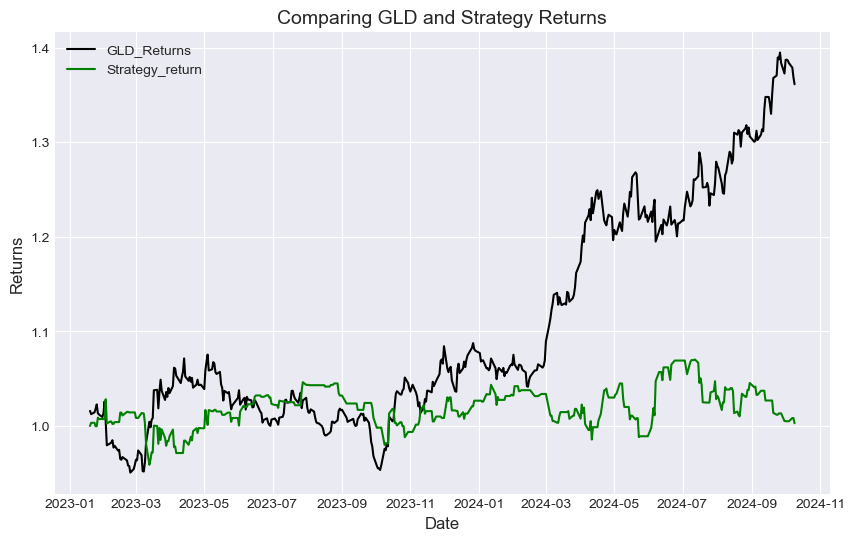

In [57]:
plt.figure(figsize =(10, 6))

# Ploting GLD returns
plt.plot(((X_test['GLD_returns'][:]+1).cumprod()),
         color = 'black', label = 'GLD_Returns')

# Ploting Sterategy return 
plt.plot(((X_test['Strategy_returns'][:]+1).cumprod()),
         color = 'Green', label =  'Strategy_return')


# x-labeling
plt.xlabel('Date', fontsize=12)

# y-labeling
plt.ylabel('Returns', fontsize=12)

# Titlename
plt.title('Comparing GLD and Strategy Returns', fontsize=14)
plt.legend()
plt.show()